In [49]:
%load_ext autoreload
%autoreload 2

# Get parent directory and add to sys.path
import sys
import os

parent_dir = os.path.dirname(os.getcwd())
sys.path.append(parent_dir)

# Require ipympl
%matplotlib widget 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [50]:
import numpy as np
from src.rocket import Rocket

rocket_obj_path = os.path.join(parent_dir, "Cartoon_rocket.obj")
rocket_params_path = os.path.join(parent_dir, "rocket.yaml")

# Rocket setup
Ts = 1 / 20
rocket = Rocket(Ts=Ts, model_params_filepath=rocket_params_path)


print("Linearization around a steady state:")

xs, us = rocket.trim()
print("Default trim function:")
print("xs = ", xs)
print("us = ", us)

xs, us = rocket.trim()
print("xs = ", xs)
print("us = ", us)

x_ref = np.array([0.0] * 9 + [1.0, 0.0, 3.0])
xs, us = rocket.trim(x_ref)
print("x_ref = ", x_ref)
print("xs = ", xs)
print("us = ", us)

Linearization around a steady state:
Default trim function:
xs =  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
us =  [ 0.      0.     66.6667  0.    ]
xs =  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
us =  [ 0.      0.     66.6667  0.    ]
x_ref =  [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 3.]
xs =  [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 3.]
us =  [ 0.      0.     66.6667  0.    ]


In [51]:
sys = rocket.linearize_sys(xs, us)
sys.info()  # see whole system


 System name: 'complete system'
------------------------------------------------------------
self.A shape: (12, 12)
self.B shape: (12, 4)
self.C shape: (12, 12)
self.D shape: (12, 4)
self.xs: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 3.]
self.us: [ 0.      0.     66.6667  0.    ]

🔹 State variables:
        wx [rad/s]
        wy [rad/s]
        wz [rad/s]
     alpha [rad]
      beta [rad]
     gamma [rad]
        vx [m/s]
        vy [m/s]
        vz [m/s]
         x [m]
         y [m]
         z [m]
→ access via self.state_name, self.state_unit

🔹 Input variables:
        d1 [rad]
        d2 [rad]
      Pavg [%]
     Pdiff [%]
→ access via self.input_name, self.input_unit

🔹 Output variables:
        wx [rad/s]
        wy [rad/s]
        wz [rad/s]
     alpha [rad]
      beta [rad]
     gamma [rad]
        vx [m/s]
        vy [m/s]
        vz [m/s]
         x [m]
         y [m]
         z [m]
→ access via self.output_name, self.output_unit
-----------------------------------------------------

In [52]:
sys_x, sys_y, sys_z, sys_roll = sys.decompose()
sys_z.info()


 System name: 'sys_z'
------------------------------------------------------------
self.A shape: (2, 2)
self.B shape: (2, 1)
self.C shape: (1, 2)
self.D shape: (1, 1)
self.xs: [0. 3.]
self.us: [66.6667]
self.idx: [ 8 11]
self.idu: [2]
self.idy: [11]

🔹 State variables:
        vz [m/s]
         z [m]
→ access via self.state_name, self.state_unit

🔹 Input variables:
      Pavg [%]
→ access via self.input_name, self.input_unit

🔹 Output variables:
         z [m]
→ access via self.output_name, self.output_unit
------------------------------------------------------------
 To check data directly, try:
   sys.A, sys.B, sys.C, sys.D
   sys.xs, sys.us, sys.state_name, etc.
------------------------------------------------------------


In [53]:
print(sys_x.A, sys_x.B, sys_x.C, sys_x.D)
print(sys_y.A, sys_y.B, sys_y.C, sys_y.D)
print(sys_z.A, sys_z.B, sys_z.C, sys_z.D)
print(sys_roll.A, sys_roll.B, sys_roll.C, sys_roll.D)

[[0.    0.    0.    0.   ]
 [1.    0.    0.    0.   ]
 [0.    9.806 0.    0.   ]
 [0.    0.    1.    0.   ]] [[-65.4748]
 [  0.    ]
 [  9.806 ]
 [  0.    ]] [[0. 0. 0. 1.]] [[0.]]
[[ 0.     0.     0.     0.   ]
 [ 1.     0.     0.     0.   ]
 [ 0.    -9.806  0.     0.   ]
 [ 0.     0.     1.     0.   ]] [[-65.4748]
 [  0.    ]
 [ -9.806 ]
 [  0.    ]] [[0. 0. 0. 1.]] [[0.]]
[[0. 0.]
 [1. 0.]] [[0.1471]
 [0.    ]] [[0. 1.]] [[0.]]
[[0. 0.]
 [1. 0.]] [[0.104]
 [0.   ]] [[0. 1.]] [[0.]]


In [54]:
Ad, Bd, Cd = sys_x._discretize(Ts)
print(Ad, Bd, Cd)

[[ 1.     -0.     -0.     -0.    ]
 [ 0.05    1.      0.      0.    ]
 [ 0.0123  0.4903  1.      0.    ]
 [ 0.0002  0.0123  0.05    1.    ]] [[-3.2737]
 [-0.0818]
 [ 0.4769]
 [ 0.0121]] [[0. 0. 0. 1.]]


In [55]:
[Ad, Bd, Cd] = sys_y._discretize(Ts)
Ad, Bd, Cd

(array([[ 1.    , -0.    , -0.    , -0.    ],
        [ 0.05  ,  1.    ,  0.    ,  0.    ],
        [-0.0123, -0.4903,  1.    ,  0.    ],
        [-0.0002, -0.0123,  0.05  ,  1.    ]]),
 array([[-3.2737],
        [-0.0818],
        [-0.4769],
        [-0.0121]]),
 array([[0., 0., 0., 1.]]))

In [56]:
[Ad, Bd, Cd] = sys_z._discretize(Ts)
Ad, Bd, Cd

(array([[1.  , 0.  ],
        [0.05, 1.  ]]),
 array([[0.0074],
        [0.0002]]),
 array([[0., 1.]]))

In [57]:
[Ad, Bd, Cd] = sys_roll._discretize(Ts)
Ad, Bd, Cd

(array([[1.  , 0.  ],
        [0.05, 1.  ]]),
 array([[0.0052],
        [0.0001]]),
 array([[0., 1.]]))

In [58]:
#########

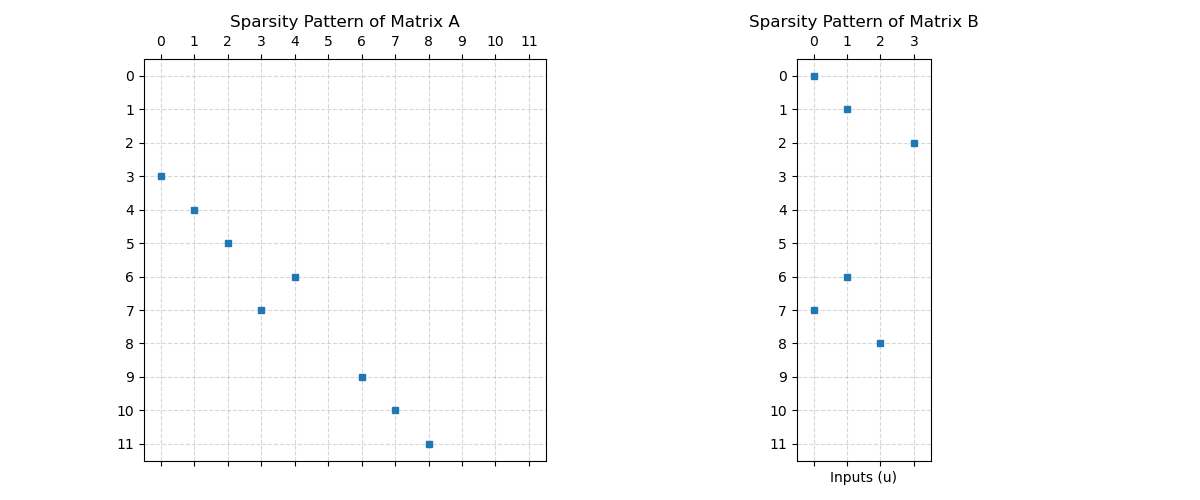

Checking coupling between subsystems...


In [59]:
import matplotlib.pyplot as plt
import numpy as np

# Engineering Analysis: Matrix Structure Visualization
# This helps answer Deliverable 2.1 by visually demonstrating the decoupling.

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Visualize A Matrix
# We use a small threshold to account for floating point noise, though theoretical zeros should be 0.
spy_A = np.abs(sys.A) > 1e-10
ax1.spy(spy_A, markersize=5)
ax1.set_title("Sparsity Pattern of Matrix A")
ax1.set_xticks(np.arange(12))
ax1.set_yticks(np.arange(12))
ax1.grid(True, which='both', linestyle='--', alpha=0.5)
# Annotate states for clarity (approximate grouping)
# States: [vx, vy, vz, wx, wy, wz, x, y, z, phi, theta, psi] (depending on definition in rocket.py)
# Usually grouped as:
# Lateral X: vy, phi, y, ... ? No, let's check the state definition in rocket.py if needed, 
# but the block diagonal structure is what matters.

# Visualize B Matrix
spy_B = np.abs(sys.B) > 1e-10
ax2.spy(spy_B, markersize=5)
ax2.set_title("Sparsity Pattern of Matrix B")
ax2.set_xticks(np.arange(4))
ax2.set_yticks(np.arange(12))
ax2.grid(True, which='both', linestyle='--', alpha=0.5)
ax2.set_xlabel("Inputs (u)")

plt.tight_layout()
plt.show()

# Print the non-zero blocks to confirm decomposition logic
print("Checking coupling between subsystems...")
# We expect specific blocks to be zero. 
# For example, X-dynamics should not affect Y-dynamics in hover.


# Todo 2 Summary

## Deliverable 2.1: System Decoupling

**Question:** Why can the system be decoupled? Explain using the structure of the A and B matrices.

**Answer:**
The system can be decoupled into four independent subsystems (Lateral X, Lateral Y, Vertical Z, and Roll) because the linearized system matrices $A$ and $B$ exhibit a **sparse, block-diagonal-like structure** at the hover trim point.

1.  **Matrix Structure Analysis**:
    *   As shown in the sparsity plots above, the full $12 \times 12$ $A$ matrix has large blocks of zeros. This indicates that the time evolution of certain state variables depends *only* on themselves and a specific subset of other states, without being influenced by the rest.
    *   Similarly, the $B$ matrix shows that specific control inputs affect only specific subsets of states. For example, the main thrust ($f_z$) primarily affects vertical velocity and position, while roll moment ($M_x$) affects roll rate and angle.

2.  **Physical Explanation**:
    *   **Hover Equilibrium**: The linearization is performed around a stationary hover condition where the rocket is upright ($\phi=\theta=0$) and velocities are zero.
    *   **Small Angle Approximation**: For small deviations from this equilibrium, the coupling terms (like Coriolis forces or geometric nonlinearities involving products of states) become negligible (second-order terms).
    *   **Symmetry**: The rocket's symmetry implies that motion in the $X-Z$ plane (pitch) is largely independent of motion in the $Y-Z$ plane (roll/yaw) for small angles.
    *   **Gravity Alignment**: Gravity acts solely along the vertical $Z$ axis, decoupling the altitude dynamics from the horizontal motion.

## Linearization and Discretization Results

*   **Trim Point**: The system was successfully trimmed at a hover state with $u_{thrust} \approx mg$.
*   **Linearization**: The nonlinear dynamics $\dot{x} = f(x,u)$ were linearized to $\dot{x} = Ax + Bu$.
*   **Decomposition**: The full system was split into:
    *   `sys_x`: Lateral position $x$, velocity $v_x$, angle $\theta$, angular rate $\omega_y$.
    *   `sys_y`: Lateral position $y$, velocity $v_y$, angle $\psi$ (yaw? actually usually $\phi$ for lateral y, depends on frame), angular rate $\omega_x$.
    *   `sys_z`: Altitude $z$, vertical velocity $v_z$.
    *   `sys_roll`: Roll angle $\phi$, roll rate $\omega_x$ (or similar, depending on specific state definition in `rocket.py`).
*   **Discretization**: All subsystems were discretized with a sampling time $T_s = 0.05$ s, yielding $A_d, B_d$ matrices suitable for the linear MPC formulation in the next steps.
